In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [166]:
import os
import tqdm
import numpy as np
import pandas as pd
import seaborn
import matplotlib.pyplot as plt 

from fragments_h5 import FragmentsH5

from fragmentomics_tools.region import Region
from fragmentomics_tools.dataframe import RegionDataFrame, DataFrameBase, SampleAndRegionDataFrame
from fragmentomics_tools.fragment_array import RegionFragmentArray, merge_fragment_arrays

from fragmentomics_tools.plot.tracks import GeneTrack, BedTrack

tqdm.tqdm.pandas()

In [4]:
from lib import make_single_strand_bndry, make_on_off_plots, load_ibd_sample_df

In [5]:
from lib import NUM_CORES, DEFAULT_MIN_MAPQ, DEFAULT_MAX_FRAG_LEN, BOUNDARY_EXPANSION_SIZE

In [6]:
df = HematopoieticGeneExpression.load()

# Make Gene-Boundary Aligned Coverage Plots

In [7]:
hge = HematopoieticGeneExpression.load()

In [8]:
hge = hge.expand_regions(left=BOUNDARY_EXPANSION_SIZE, right=BOUNDARY_EXPANSION_SIZE, strand_aware=True)

In [9]:
srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(hge, load_ibd_sample_df()).attach_fragment_arrays(num_cores=64)
srdf['n_fragments']  = [fa.n_fragments for fa in srdf.fragment_array]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312354/312354 [04:44<00:00, 1098.49it/s]


CPU times: user 1min 52s, sys: 27.8 s, total: 2min 19s
Wall time: 2min 17s


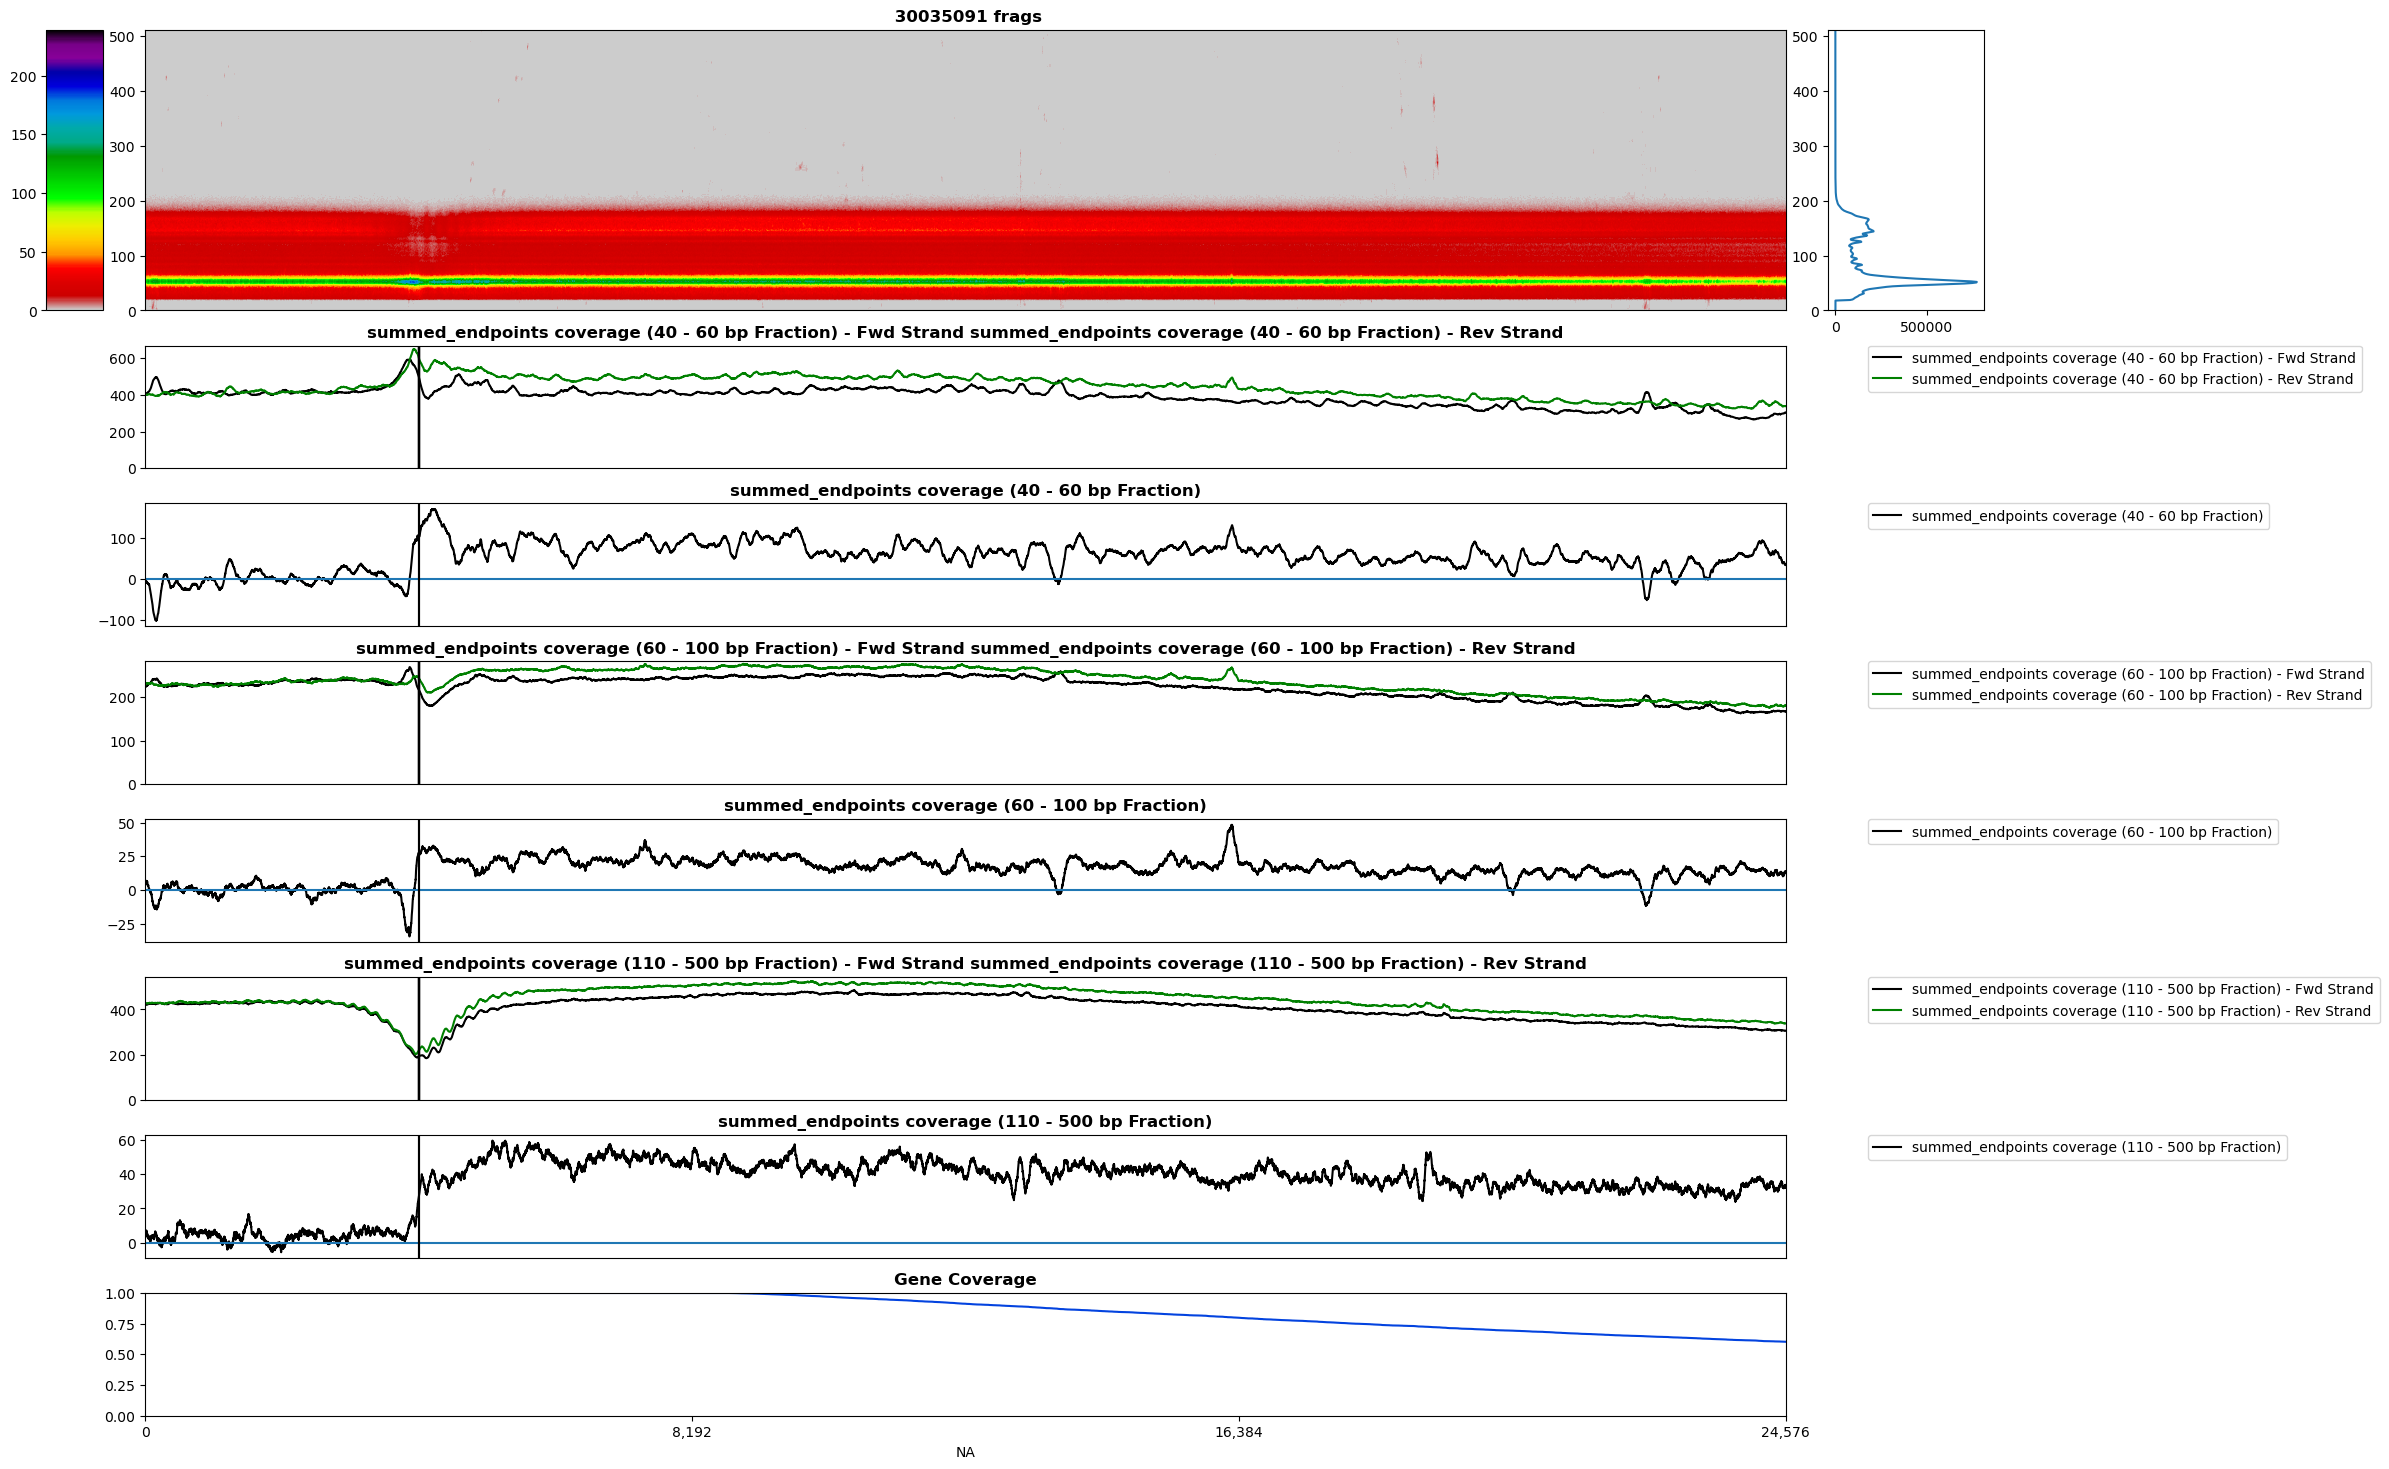

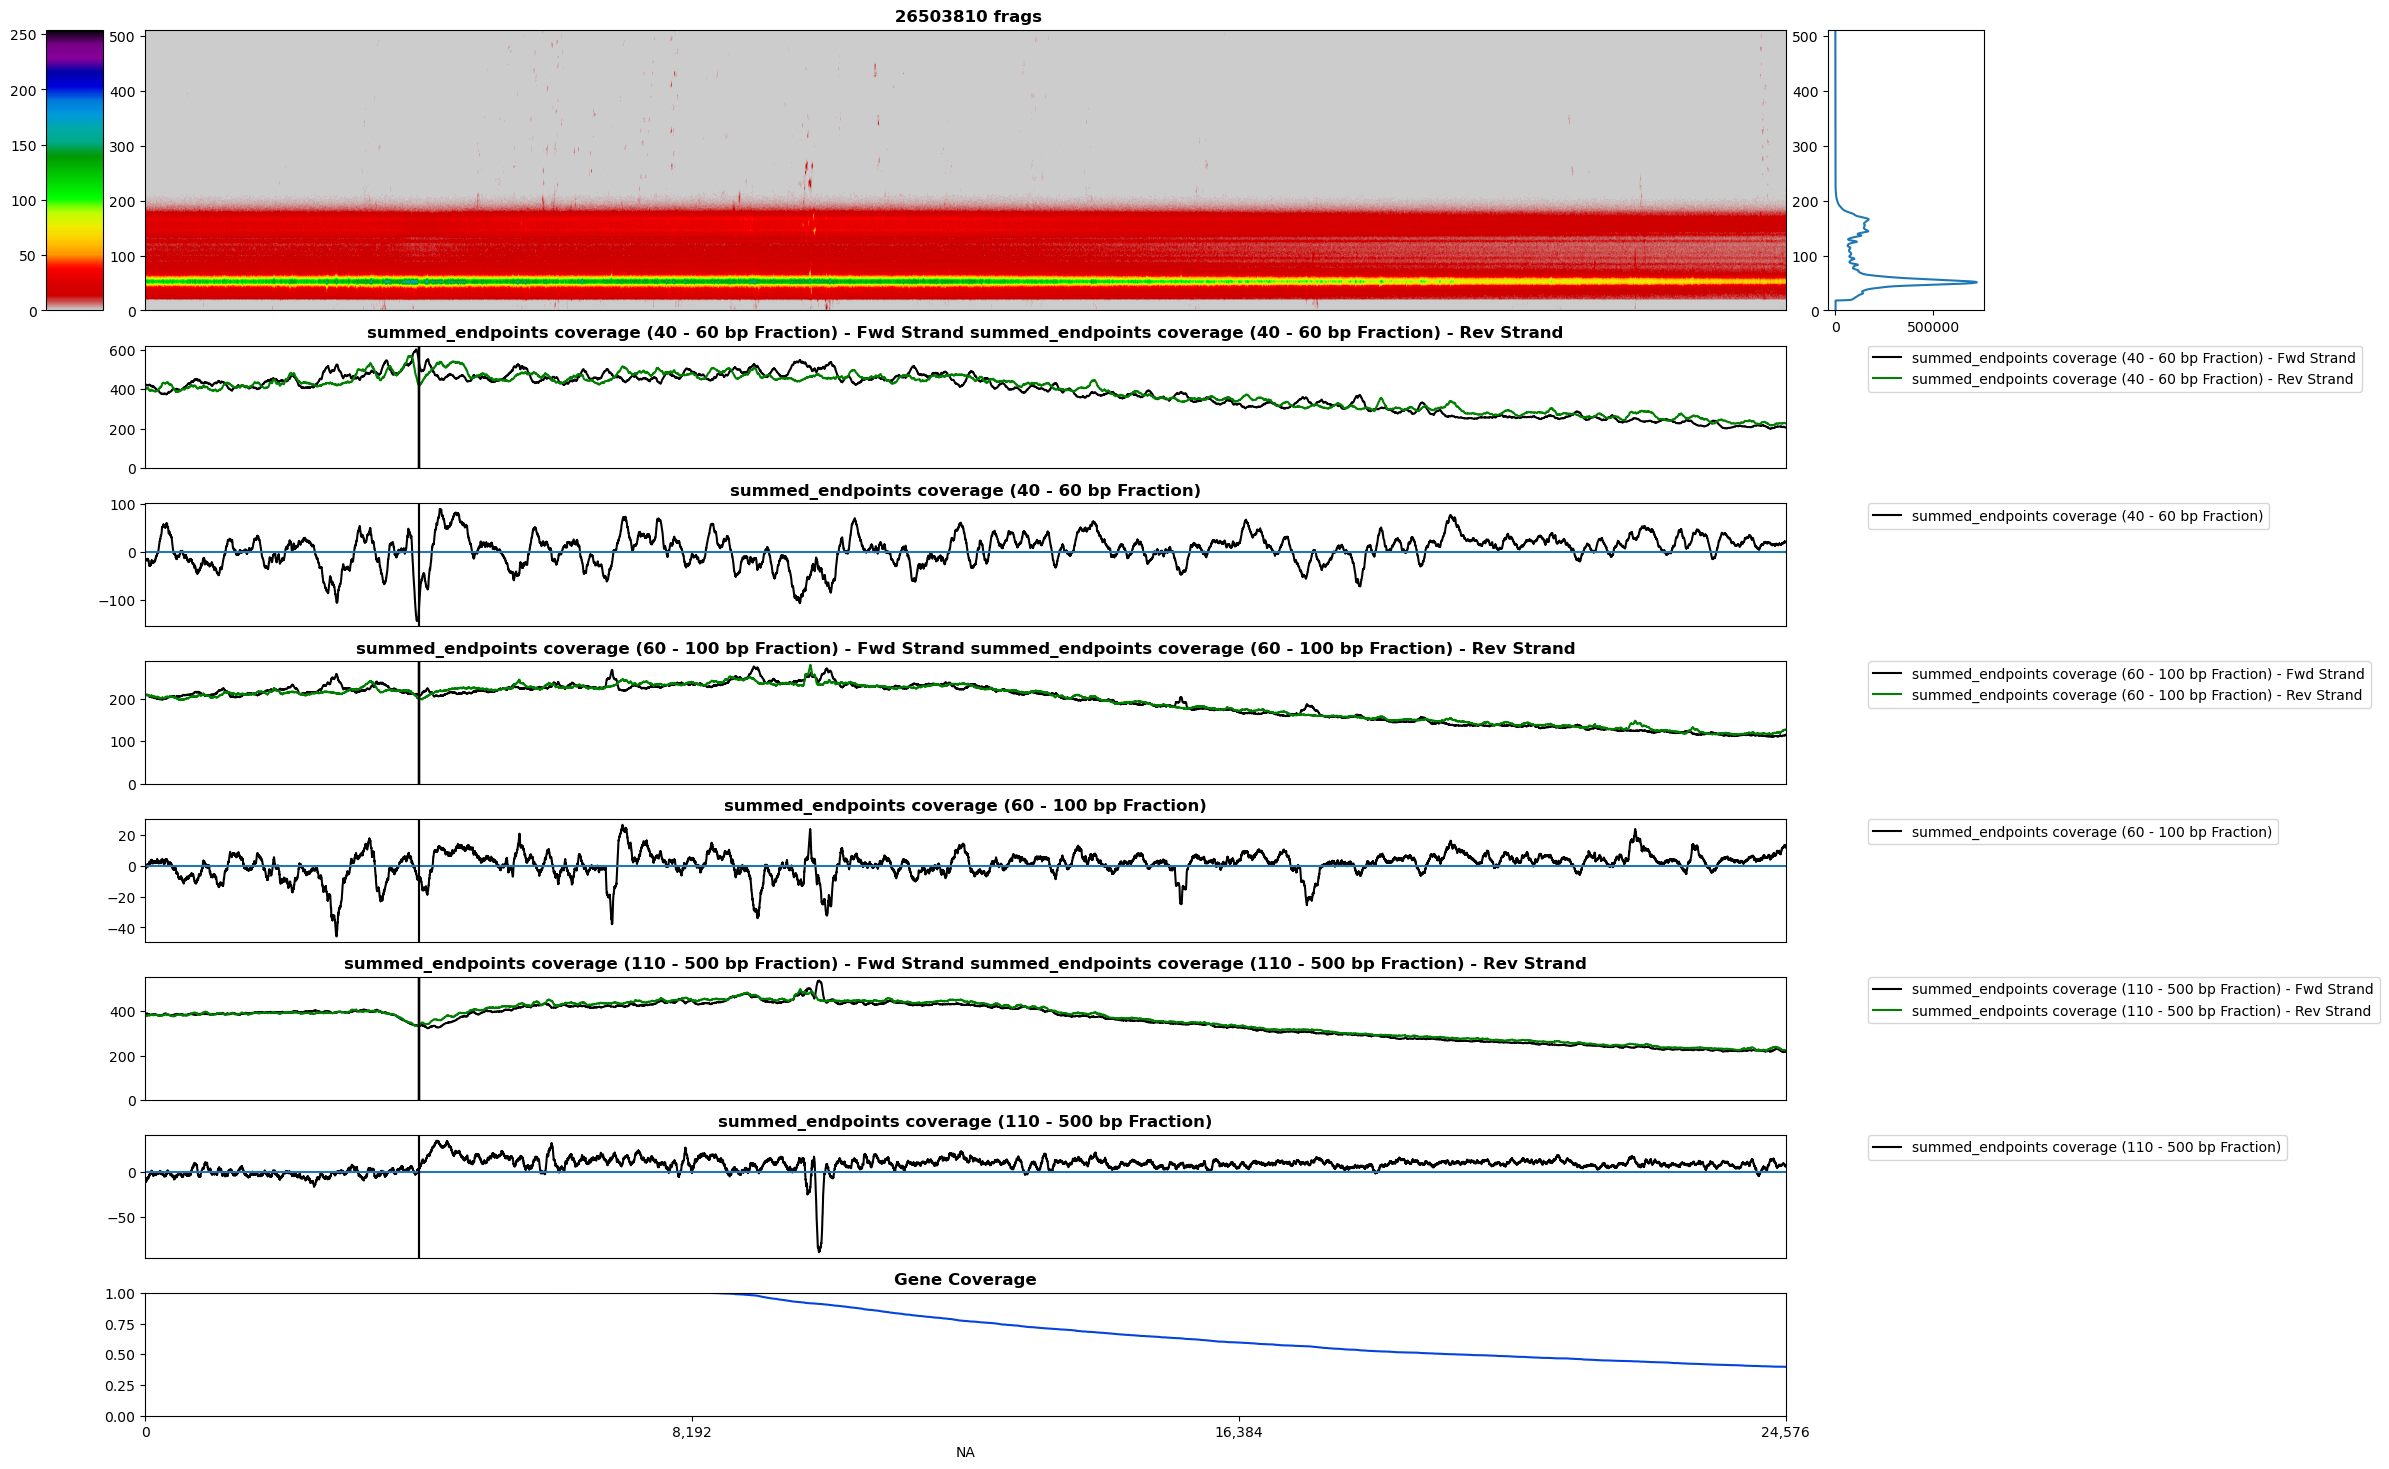

In [10]:
%%time
make_on_off_plots(srdf, 'tss')

# Score Regions

In [11]:
new_tpm_ranges = [(0, 0.1), (0.1, 1), (1, 5), (5, 10), (10, 20), (20, 70), (70, 500)]

def add_tpm_bucket(df):
    df['tpm_bucket'] = None
    for i, (start, stop) in enumerate(new_tpm_ranges):
        df.loc[(start <= df.expression) & (df.expression < stop), 'tpm_bucket'] = f"{i+1}: TPM {str(start).zfill(1)}-{str(stop).zfill(1)}"
    return df


def score_fa(record, low_fl=30, high_fl=500):
    fa = record.fragment_array.drop_duplicate_fragments()
    fa = fa.subset_fragment_lengths(low_fl, high_fl)
    strands, counts = np.unique(fa.fragment_strands, return_counts=True)
    if fa.strand == '+':
        fwd_mask = (strands == '+')
    elif fa.strand == '-':
        fwd_mask = (strands == '-')
    else:
        assert False, f"UNREACHABLE: ({fa.strand})"

    if counts.sum() < 100 or len(strands) != 2:
        return None

    res = (counts[~fwd_mask] - counts[fwd_mask])/counts.sum()
    assert len(res) == 1
    return float(res[0])


In [12]:
df = add_tpm_bucket(srdf)

In [13]:
scores = df.progress_apply(score_fa, axis=1).rename('score')
scores = RegionDataFrame(pd.concat([pd.DataFrame(df), scores], axis=1), ref=df.ref)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312354/312354 [02:44<00:00, 1894.26it/s]


In [14]:
scores.head()

,gene_name,gene_id,contig,strand,start,stop,expression,sample_id,label,frag_h5,DIAGNOSIS,ENDO_CATEGORY,Cluster,SITE_NUMBER,fragment_array,n_fragments,tpm_bucket,score
0,A1BG,ENSG00000121410,chr19,-,58341087,58357588,62.542394,RD-56170,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 2,Site_13,"RegionFragmentArray(n_frags=423, region=chr19:...",423,6: TPM 20-70,-0.061425
1,A1BG,ENSG00000121410,chr19,-,58341087,58357588,62.542394,RD-56169,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 6,Site_13,"RegionFragmentArray(n_frags=508, region=chr19:...",508,6: TPM 20-70,-0.160896
2,A1BG,ENSG00000121410,chr19,-,58341087,58357588,62.542394,RD-56168,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 3,Site_13,"RegionFragmentArray(n_frags=270, region=chr19:...",270,6: TPM 20-70,-0.023077
3,A1BG,ENSG00000121410,chr19,-,58341087,58357588,62.542394,RD-56167,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 1,Site_13,"RegionFragmentArray(n_frags=409, region=chr19:...",409,6: TPM 20-70,0.005208
4,A1BG,ENSG00000121410,chr19,-,58341087,58357588,62.542394,RD-56165,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 3,Site_13,"RegionFragmentArray(n_frags=245, region=chr19:...",245,6: TPM 20-70,-0.250000


In [15]:
scores.groupby('tpm_bucket').score.agg(['count', 'mean', 'std'])

,count,mean,std
tpm_bucket,,,
1: TPM 0-0.1,73969,0.005862,0.121016
2: TPM 0.1-1,33617,0.018066,0.101328
3: TPM 1-5,31103,0.019711,0.097785
4: TPM 5-10,20432,0.030179,0.088476
5: TPM 10-20,30395,0.032592,0.086661
6: TPM 20-70,71278,0.038335,0.084991
7: TPM 70-500,45697,0.041209,0.083561


# Marker Gene Analysis

In [16]:
marker_genes = pd.read_table("/scratch/karius/reference/markers.immune_vs_epithelial.tsv", sep=" ")
up_marker_genes = marker_genes.query("p_val_adj < 0.01 and avg_log2FC < -4").assign(direction='up_in_colon')
down_marker_genes = marker_genes.query("p_val_adj < 0.01 and avg_log2FC > 7").assign(direction='down_in_colon')
marker_genes = pd.concat([up_marker_genes, down_marker_genes])
marker_genes = pd.DataFrame(scores).set_index("gene_name").join(marker_genes, how='inner').reset_index()

In [17]:
pd.DataFrame(marker_genes.groupby(["label", 'sample_id', "direction"]).score.agg(['count', 'mean']).reset_index()).rename(columns={'mean': 'mean_score'}).groupby(["label", "direction"])[['mean_score', 'count']].agg(['mean', 'std'])

mean_score                 count          
                          mean       std        mean       std
label direction                                               
1     down_in_colon   0.016353  0.005532  158.833333  0.408248
      up_in_colon    -0.020597  0.010566   25.000000  0.000000
2     down_in_colon   0.014480  0.005015  159.000000  0.000000
      up_in_colon    -0.009437  0.004378   25.000000  0.000000
3     down_in_colon   0.015620  0.002760  158.750000  0.500000
      up_in_colon    -0.005309  0.004358   25.000000  0.000000
4     down_in_colon   0.020378  0.003233  158.666667  0.577350
      up_in_colon    -0.006805  0.009505   25.000000  0.000000

# Visualize Individual Genes

In [18]:
_3 = marker_genes.query("direction == 'up_in_colon' and label==4").set_index(['gene_id', 'gene_name'])[['score']]
_1 = marker_genes.query("direction == 'up_in_colon' and label==1").set_index(['gene_id', 'gene_name'])[['score']]
df = pd.DataFrame(_1.groupby(_1.index).score.agg('mean').sort_values()).join(_3.groupby(_3.index).score.mean().sort_values(), how='inner',  lsuffix='_remission', rsuffix='_severe')

In [19]:
# df = df.query("score_severe > 0")

In [20]:
(df.score_severe - df.score_remission).sort_values()

(ENSG00000168748, CA7)         -0.099096
(ENSG00000204614, TRIM40)      -0.076668
(ENSG00000073737, DHRS9)       -0.052839
(ENSG00000204539, CDSN)        -0.045282
(ENSG00000168447, SCNN1B)      -0.024255
(ENSG00000198488, B3GNT6)      -0.009999
(ENSG00000204571, KRTAP5-11)   -0.006523
(ENSG00000166183, ASPG)        -0.004333
(ENSG00000073734, ABCB11)      -0.001235
(ENSG00000160868, CYP3A4)      -0.000595
(ENSG00000175329, ISX)          0.000144
(ENSG00000137869, CYP19A1)      0.000291
(ENSG00000106536, POU6F2)       0.001210
(ENSG00000166828, SCNN1G)       0.006020
(ENSG00000214814, FER1L6)       0.007107
(ENSG00000039987, BEST2)        0.015416
(ENSG00000011083, SLC6A7)       0.018243
(ENSG00000196091, MYBPC1)       0.022427
(ENSG00000167800, TBX10)        0.025243
(ENSG00000169876, MUC17)        0.026287
(ENSG00000105996, HOXA2)        0.041052
(ENSG00000142959, BEST4)        0.056013
(ENSG00000261210, CLEC19A)      0.081207
(ENSG00000105523, FAM83E)       0.154278
(ENSG00000137251

Text(0.5, 0.98, 'TBX10')

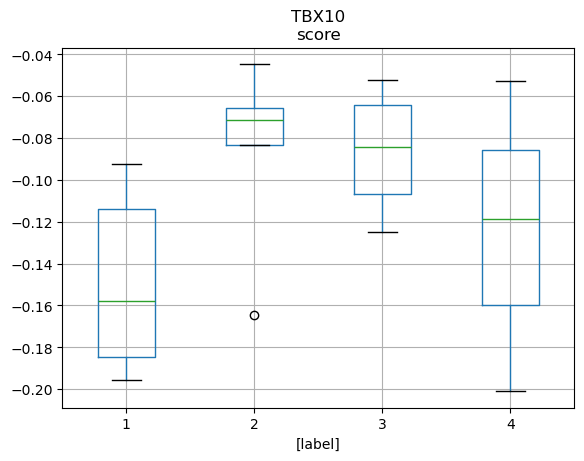

In [183]:
GENE_NAME = 'TBX10'
sub_df = scores.query("gene_name == @GENE_NAME")
pd.DataFrame(sub_df)[['label', 'score']].boxplot(by='label')
plt.suptitle(GENE_NAME)

In [215]:
merged_fa = merge_fragment_arrays([fa for fa in sub_df.fragment_array.tolist()])
merged_fa.region, merged_fa.n_fragments

(Region(chr11:-:67627207-67643859), 7902)

In [216]:
# merged_fa = merged_fa.truncate(left_amt=12600).right_resize(100)

In [217]:
merged_fa.region

Region(chr11:-:67627207-67643859)

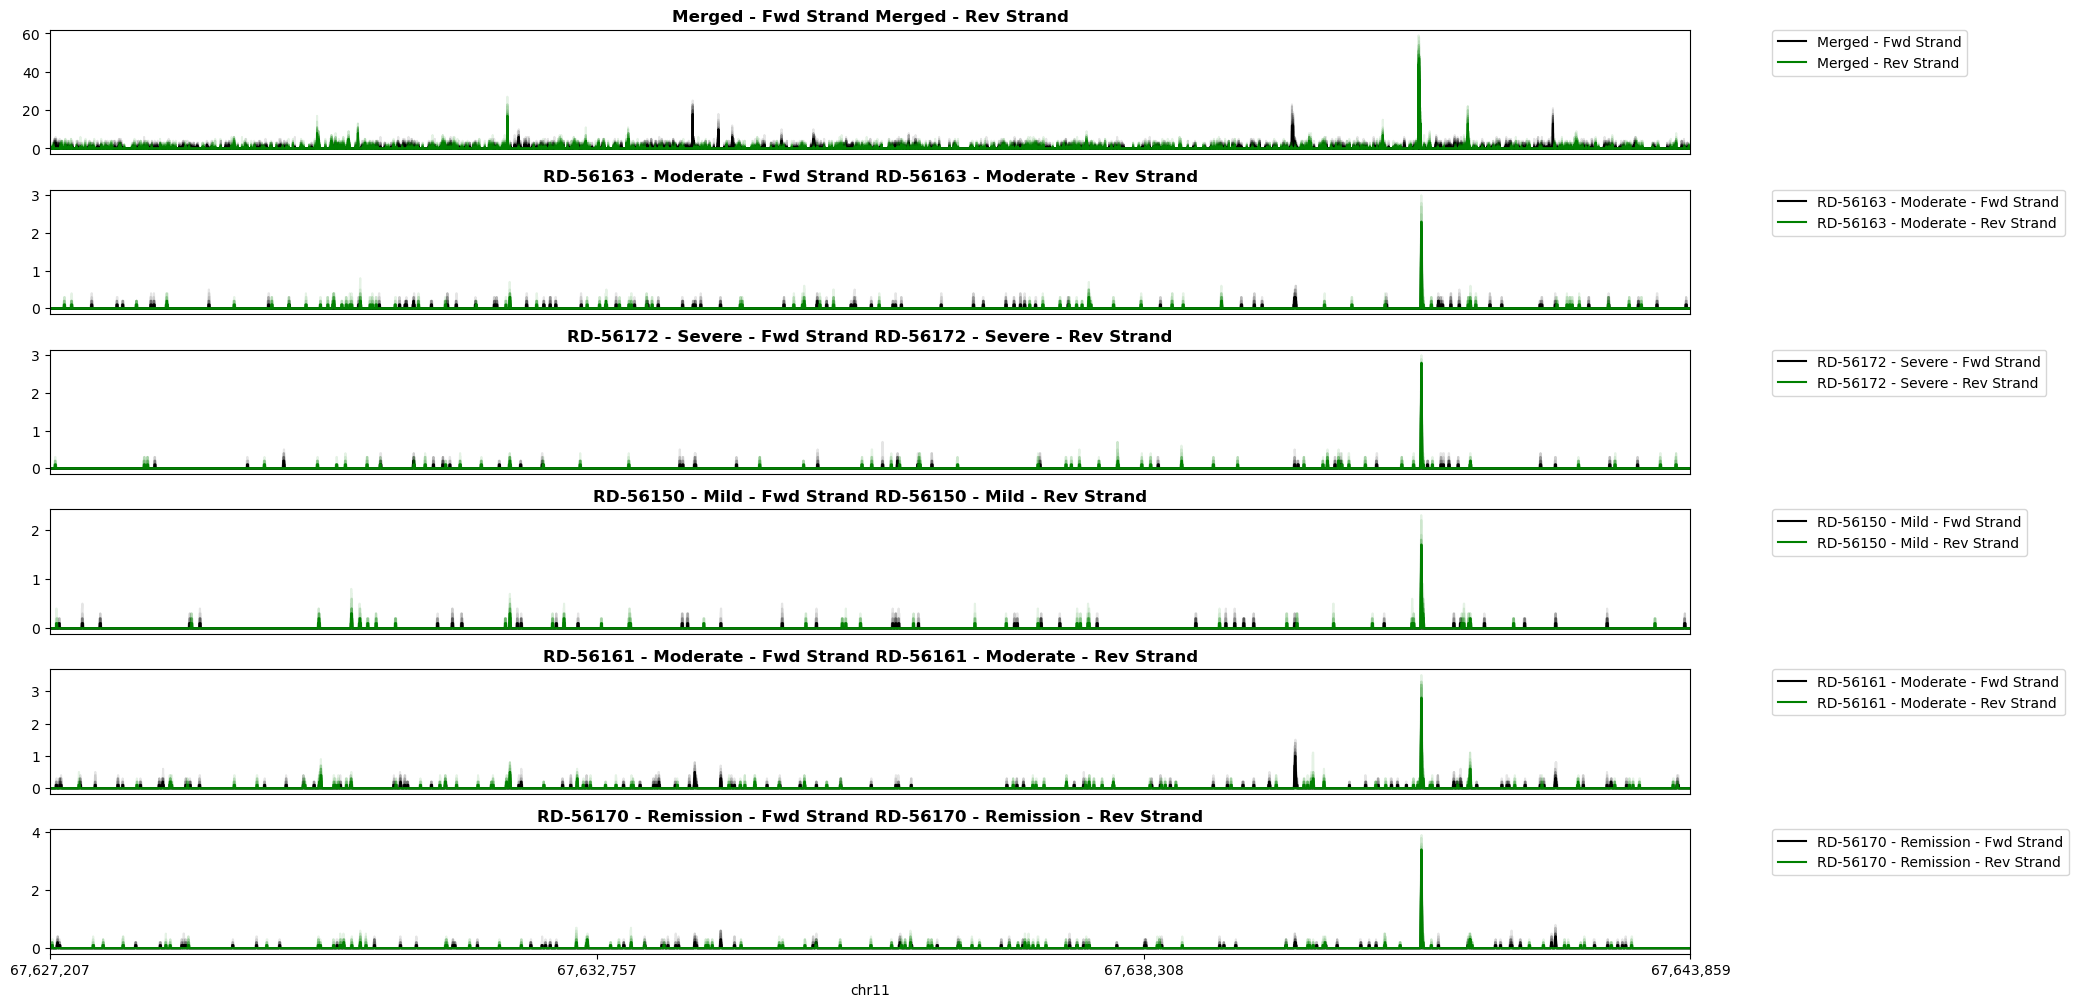

In [218]:
from fragmentomics_tools.plot.tracks import Tracks, StrandSplitCoverageTrack
tracks = Tracks()
tracks.append(StrandSplitCoverageTrack(merged_fa, merged_fa.region, coverage_type='left_endpoint', smooth_window=None, fraction=(40, 60), name="Merged"))
for record in sub_df.sample(5).itertuples():
    tracks.append(StrandSplitCoverageTrack(record.fragment_array, record.fragment_array.region, fraction=(40, 60), name=f"{record.sample_id} - {record.ENDO_CATEGORY}"))
fig, axs = tracks.plot()

In [556]:
merged_fa

RegionFragmentArray(n_frags=10418, region=chr19:-:48595865-48618723, length=22858, starts_0=[-11,74, ..., 22815,22821], stops_0=[19,126, ..., 22919,22907], strand=[+,+, ..., +,-], weights=[1.0,1.0, ..., 1.0,1.0], first_covered_base_weights=[1.0,1.0, ..., 1.0,1.0], last_covered_base_weights=[1.0,1.0, ..., 1.0,1.0], num_cpgs=[1,1, ..., 1,1], num_meth_cpgs=[1,1, ..., 1,1], max_frag_len=511)

In [557]:
fa = merged_fa
fa

RegionFragmentArray(n_frags=10418, region=chr19:-:48595865-48618723, length=22858, starts_0=[-11,74, ..., 22815,22821], stops_0=[19,126, ..., 22919,22907], strand=[+,+, ..., +,-], weights=[1.0,1.0, ..., 1.0,1.0], first_covered_base_weights=[1.0,1.0, ..., 1.0,1.0], last_covered_base_weights=[1.0,1.0, ..., 1.0,1.0], num_cpgs=[1,1, ..., 1,1], num_meth_cpgs=[1,1, ..., 1,1], max_frag_len=511)

In [558]:
fa = fa.truncate(left_amt=BOUNDARY_EXPANSION_SIZE-100, right_amt=BOUNDARY_EXPANSION_SIZE-100)
fa.region # truncate(right_amt=BOUNDARY_EXPANSION_SIZE*2).region

Region(chr19:-:48599861-48614727)

In [559]:
# fa = fa.right_resize(4096).resize(1024)

In [560]:
from fragmentomics_tools.plot.tracks import GeneTrack, BedTrack
tracks = make_single_strand_bndry(fa, coverage_type='right_endpoint', include_vplot=False)
tracks.insert(1, GeneTrack("/scratch/karius/annotation/gencode/gencode.v45.basic.annotation.bed.gz", fa.region))
tracks.insert(1, BedTrack("/home/nboley/src/Ravel/data/repo_data_manifest/annotations/GRCh38_extras/hg38-repeats.sorted.bed.gz", fa.region))
tracks.insert(1, BedTrack("/scratch/karius/annotation/mappability.simple_repeats.sorted.bed.gz", fa.region))

(<Figure size 2500x1800 with 9 Axes>,
 [<Axes: title={'center': 'right_endpoint coverage (40 - 60 bp Fraction) - Fwd Strand right_endpoint coverage (40 - 60 bp Fraction) - Rev Strand'}>,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: title={'center': 'right_endpoint coverage (40 - 60 bp Fraction)'}>,
  <Axes: title={'center': 'right_endpoint coverage (60 - 100 bp Fraction) - Fwd Strand right_endpoint coverage (60 - 100 bp Fraction) - Rev Strand'}>,
  <Axes: title={'center': 'right_endpoint coverage (60 - 100 bp Fraction)'}>,
  <Axes: title={'center': 'right_endpoint coverage (110 - 500 bp Fraction) - Fwd Strand right_endpoint coverage (110 - 500 bp Fraction) - Rev Strand'}>,
  <Axes: title={'center': 'right_endpoint coverage (110 - 500 bp Fraction)'}, xlabel='chr19'>])

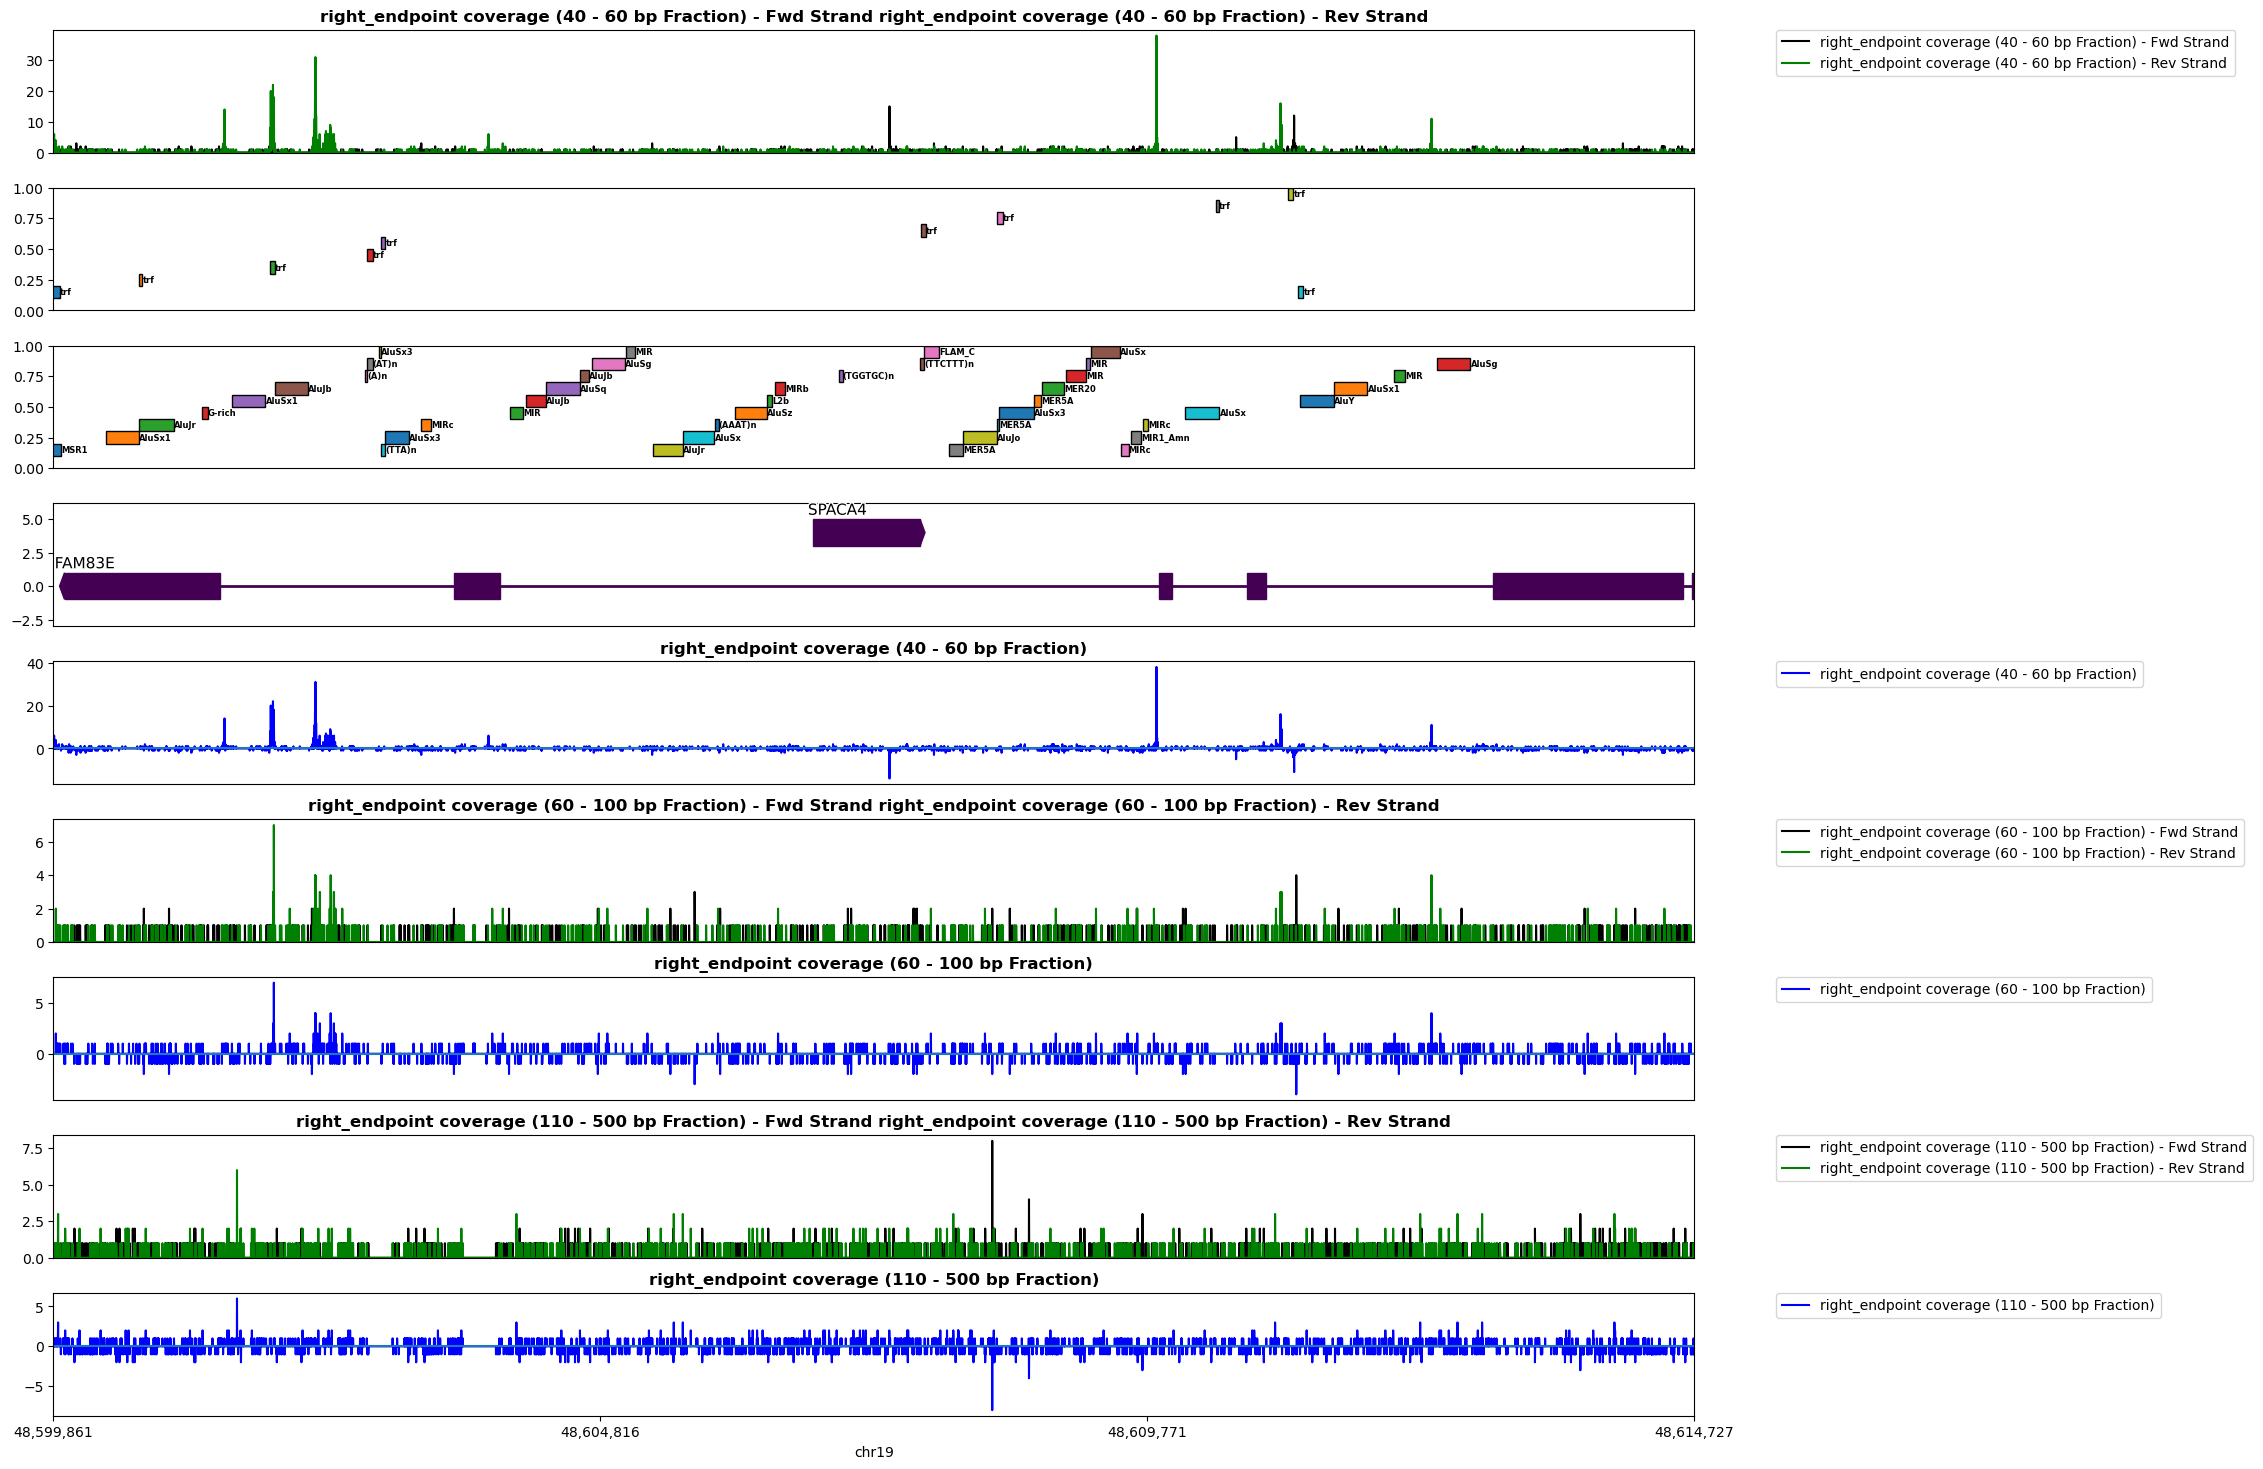

In [561]:
tracks.plot()

(<Figure size 2500x1000 with 5 Axes>,
 [<Axes: title={'center': 'right_endpoint coverage (40 - 60 bp Fraction) - Fwd Strand right_endpoint coverage (40 - 60 bp Fraction) - Rev Strand'}>,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: title={'center': 'right_endpoint coverage (40 - 60 bp Fraction)'}, xlabel='chr19'>])

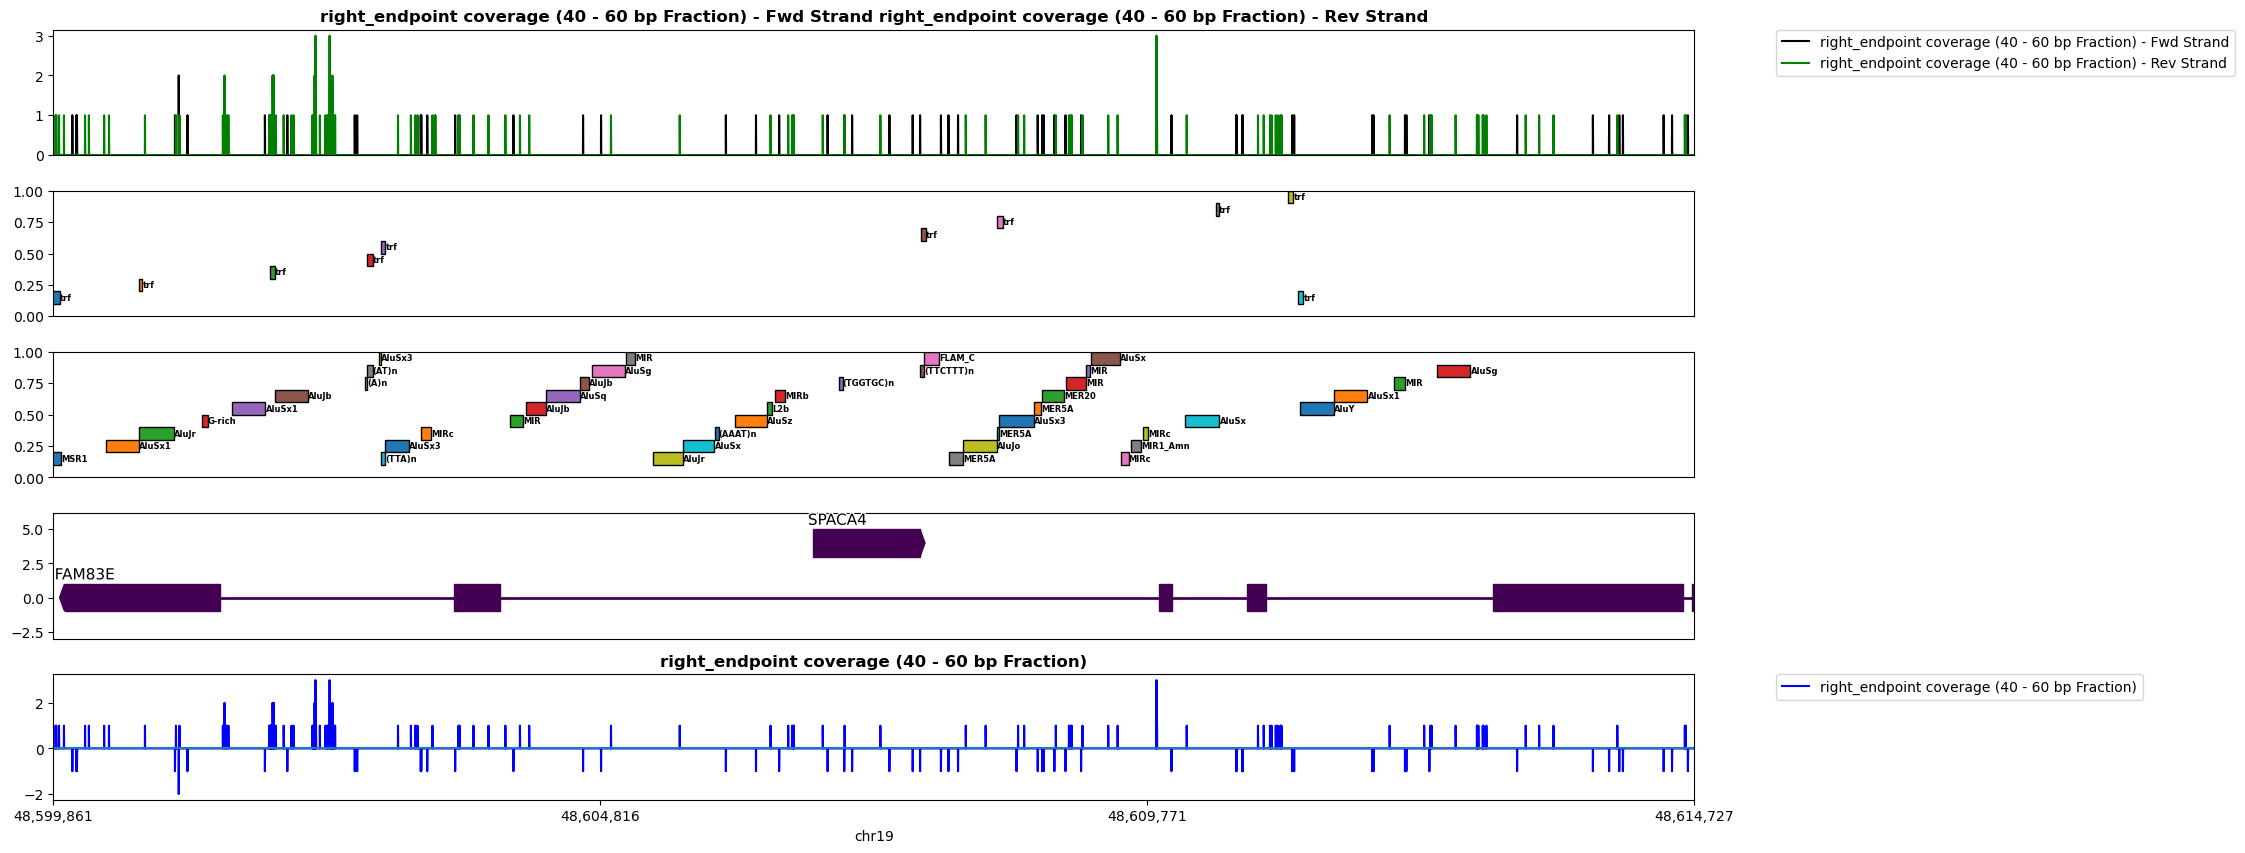

In [472]:
tracks.plot()

In [234]:
fa

RegionFragmentArray(n_frags=224, region=chr19:-:48599861-48603957, length=4096, starts_0=[-139,-81, ..., 4022,4081], stops_0=[12,88, ..., 4093,4257], strand=[-,-, ..., -,+], weights=[1.0,1.0, ..., 1.0,1.0], first_covered_base_weights=[1.0,1.0, ..., 1.0,1.0], last_covered_base_weights=[1.0,1.0, ..., 1.0,1.0], num_cpgs=[1,1, ..., 1,1], num_meth_cpgs=[1,1, ..., 1,1], max_frag_len=511)

In [ ]:
tracks.append(load_genome_coverage_track('hg38'))
tracks.append(load_motif_track('CTCF'))

In [ ]:
# Loading samples
# standardized for loading samples for different anaysis
load_ibd_sample_df()
Samples.load_collection('ibd_pilot') -> sdf

# Loading reference data
gencode
hg38 fasta
blacklist
motif_pwms



In [322]:
df = pd.read_table("/scratch/karius/annotation/gencode/gencode.v45.basic.annotation.gtf.gz", comment="#")

In [323]:
df.head()

,chr1,HAVANA,gene,11869,14409,.,+,..1,"gene_id ""ENSG00000290825.1""; gene_type ""lncRNA""; gene_name ""DDX11L2""; level 2; tag ""overlaps_pseudogene"";"
0,chr1,HAVANA,transcript,11869,14409,.,+,.,"gene_id ""ENSG00000290825.1""; transcript_id ""EN..."
1,chr1,HAVANA,exon,11869,12227,.,+,.,"gene_id ""ENSG00000290825.1""; transcript_id ""EN..."
2,chr1,HAVANA,exon,12613,12721,.,+,.,"gene_id ""ENSG00000290825.1""; transcript_id ""EN..."
3,chr1,HAVANA,exon,13221,14409,.,+,.,"gene_id ""ENSG00000290825.1""; transcript_id ""EN..."
4,chr1,HAVANA,gene,12010,13670,.,+,.,"gene_id ""ENSG00000223972.6""; gene_type ""transc..."


CPU times: user 12.6 s, sys: 300 ms, total: 12.9 s
Wall time: 12.9 s


In [568]:
len(list(frag_h5.fetch()))*2

254

In [ ]:
# "/scratch/karius/annotation/gencode/gencode.v45.basic.annotation.gtf.gz",
# bedtools sort -i /scratch/karius/annotation/gencode/gencode.v45.basic.annotation.bed > /scratch/karius/annotation/gencode/gencode.v45.basic.annotation.sorted.bed
# rm /scratch/karius/annotation/gencode/gencode.v45.basic.annotation.bed
# bgzip /scratch/karius/annotation/gencode/gencode.v45.basic.annotation.sorted.bed
# mv /scratch/karius/annotation/gencode/gencode.v45.basic.annotation.sorted.bed.gz /scratch/karius/annotation/gencode/gencode.v45.basic.annotation.bed.gz 

# TINAG Fragments

In [176]:
def plot(fa):
    tracks = Tracks()
    tracks.append(StrandSplitCoverageTrack(fa, fa.region, coverage_type='left_endpoint', smooth_window=None, n_boot_coverage=None, fraction=(40, 60), name="RD-56170"))
    tracks.append(BedTrack("/home/nboley/src/Ravel/data/repo_data_manifest/annotations/GRCh38_extras/hg38-repeats.sorted.bed.gz", fa.region))
    tracks.append(BedTrack("/scratch/karius/annotation/mappability.simple_repeats.sorted.bed.gz", fa.region))
    tracks.plot()


In [177]:
sdf = load_ibd_sample_df()

In [178]:
region = Region.from_region_str("chr6:+:54309970-54310994")

In [179]:
fa = RegionFragmentArray.from_fragments_h5(sdf.set_index('sample_id').loc['RD-56170'].frag_h5, region, include_fragment_strand=True)

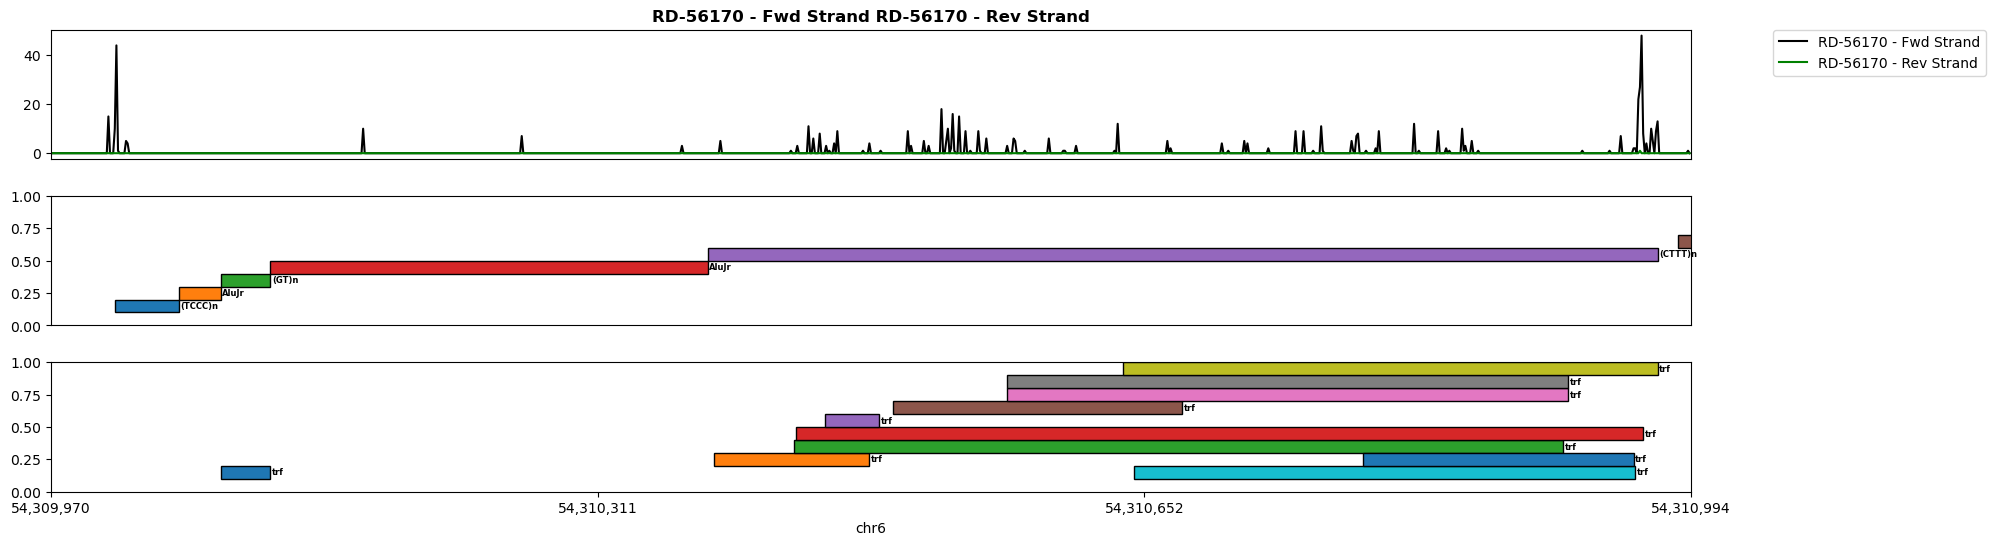

In [180]:
plot(fa)

In [181]:
fa = fa.right_resize(100).truncate(left_amt=30)
fa.region

Region(chr6:+:54310000-54310070)

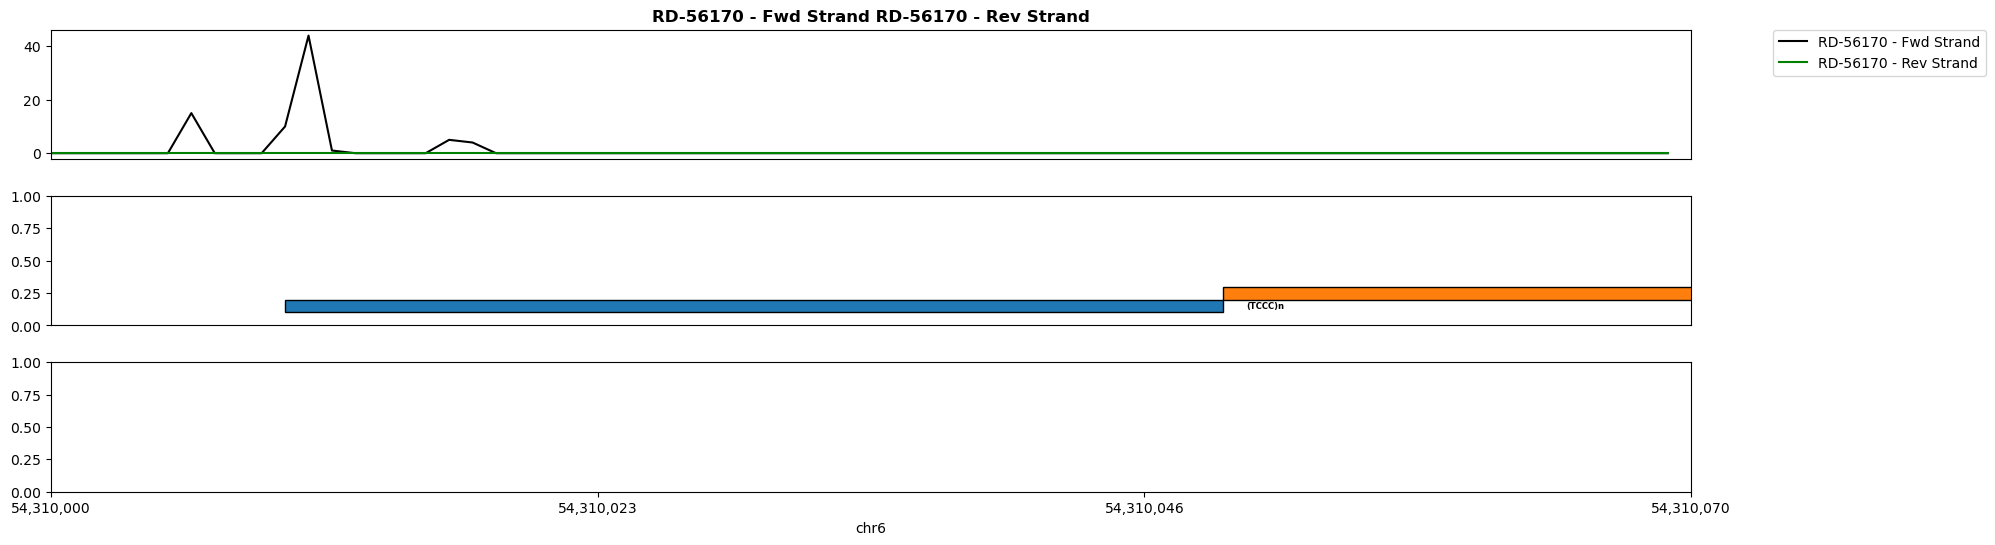

In [182]:
plot(fa)

In [156]:
import pysam

# fa = fa.drop_duplicate_fragments()
with pysam.FastaFile("/home/nboley/src/Ravel/data/repo_data_manifest/reference/GRCh38/GRCh38.p12.genome.fa.gz") as fasta:
    seq = bytearray(fa.region.get_sequence(fasta))
aligned = [seq, '.']
for start, stop, strand in list(zip(fa.starts_0, fa.stops_0, fa.fragment_strands)):
    start = max(0, start)
    stop = min(stop, len(seq))
    subseq = bytearray((' '*len(seq)).encode())
    subseq[start:stop] = seq[start:stop]
    print(subseq, strand)
# sorted(list(zip(fa.starts_0, fa.stops_0, fa.fragment_strands)), key=lambda x: x[0])

bytearray(b'TAAACAGCT                                                             ') -
bytearray(b'TAAACAGCT                                                             ') -
bytearray(b'      GCTTTCCCTTCTTCCCTCCCTCCACACCTCCATCCTTCTCTCCCTTTCTT              ') +
bytearray(b'      GCTTTCCCTTCTTCCCTCCCTCCACACCTCCATCCTTCTCTCCCTTTCTTTT            ') +
bytearray(b'      GCTTTCCCTTCTTCCCTCCCTCCACACCTCCATCCTTCTCTCCCTTTCTT              ') +
bytearray(b'      GCTTTCCCTTCTTCCCTCCCTCCACACCTCCATCCTTCTCTCCCTTTCTTTT            ') +
bytearray(b'      GCTTTCCCTTCTTCCCTCCCTCCACACCTCCATCCTTCTCTCCCTTTCTT              ') +
bytearray(b'      GCTTTCCCTTCTTCCCTCCCTCCACACCTCCATCCTTCTCTCCCTTTCTT              ') +
bytearray(b'      GCTTTCCCTTCTTCCCTCCCTCCACACCTCCATCCTTCTCTCCCTTTCTTTT            ') +
bytearray(b'      GCTTTCCCTTCTTCCCTCCCTCCACACCTCCATCCTTCTCTCCCTTTCTTTT            ') +
bytearray(b'      GCTTTCCCTTCTTCCCTCCCTCCACACCTCCATCCTTCTCTCCCTTTCTTTT            ') +
bytearray(b'      GCTTTCCCTTCTTCCCTCCCTCCAC

# FAM83E Fragments

In [609]:
region = Region("chr19", 48601653, 48601909)

In [672]:
fa = RegionFragmentArray.from_fragments_h5(sdf.set_index('sample_id').loc['RD-56170'].frag_h5, region, include_fragment_strand=True)
fa = fa.truncate(left_amt=115)
fa = fa.right_resize(100)
with pysam.FastaFile("/home/nboley/src/Ravel/data/repo_data_manifest/reference/GRCh38/GRCh38.p12.genome.fa.gz") as fasta:
    seq = bytearray(fa.region.get_sequence(fasta))
aligned = []
for start, stop, strand in list(zip(fa.starts_0, fa.stops_0, fa.fragment_strands)):
    start = max(0, start)
    stop = min(stop, len(seq))
    subseq = bytearray((' '*len(seq)).encode())
    subseq[start:stop] = seq[start:stop]
    print(subseq, strand)
# sorted(list(zip(fa.starts_0, fa.stops_0, fa.fragment_strands)), key=lambda x: x[0])

bytearray(b'AAAAAAAAAGGAAGTGATAG                                                                                ') -
bytearray(b'AAAAAAAAAG                                                                                          ') +
bytearray(b'    AAAAAGGAAGTGATAGAGGATTTGAGGGAGGTGGAAGGAGATGG                                                    ') -
bytearray(b'    AAAAAGGAAGTGATAGAGGATTTGAGGGAGGTGGAAGGAGATGG                                                    ') -
bytearray(b'    AAAAAGGAAGTGATAGAGGATTTGAGGGAGGTGGAAGGAGATGG                                                    ') -
bytearray(b'    AAAAAGGAAGTGATAGAGGATTTGAGGGAGGTGGAAGGAGATGG                                                    ') -
bytearray(b'    AAAAAGGAAGTGATAGAGGATTTGAGGGAGGTGGAAGGAGATGGTGGAGGAGGGAAGGGAGGGAAGA                             ') -
bytearray(b'    AAAAAGGAAGTGATAGAGGATTTGAGGGAGGTGGAAGGAGATGGTGGAGGAGGGAAGGGAGGGAAGA                             ') -
bytearray(b'    AAAAAGGAAGTGATAGAGGATTTGAGGGAGGTGGAAGGAGATGG    

In [656]:
seq

array(b'GACTCAGTCTCAAAAAAAAAAAAAGGAAGTGATAGAGGATTTGAGGGAGGTGGAAGGAGATGGTGGAGGAGGGAAGGGAGGGAAGAGAGGAGAGAGGGAG',
      dtype='|S100')

In [637]:
import pysam

seq

b'ACTCGGGAGGCTGAGGCAGGAGAATCGCTTGAACCCGGAAGGGAGAGATTGCAGTGAGCTGAGATAGCGCCACCGCACTCCAGCCTGGGCATCAGAACAAGACTCAGTCTCAAAAAAAAAAAAAGGAAGTGATAGAGGATTTGAGGGAGGTGGAAGGAGATGGTGGAGGAGGGAAGGGAGGGAAGAGAGGAGAGAGGGAGGAGAGAGATGGAGGCCGGACGCGGTGGCTCACACCAGTAATCCCAGCACTTTGGGA'

[(-32, 135, '-'),
 (72, 125, '+'),
 (119, 163, '-'),
 (119, 186, '-'),
 (125, 172, '-'),
 (125, 173, '-'),
 (126, 179, '-'),
 (127, 176, '-'),
 (129, 201, '-'),
 (131, 174, '-'),
 (131, 178, '-'),
 (131, 182, '-'),
 (141, 185, '-'),
 (141, 198, '-'),
 (143, 183, '-'),
 (143, 195, '-'),
 (143, 196, '-'),
 (143, 198, '-'),
 (144, 200, '-'),
 (147, 281, '-'),
 (149, 197, '-'),
 (150, 195, '-'),
 (152, 205, '-'),
 (152, 208, '-'),
 (157, 308, '-'),
 (163, 206, '-'),
 (165, 206, '-'),
 (170, 224, '-'),
 (233, 376, '-'),
 (248, 295, '-')]